## Load Dataset

In [2]:
import numpy as np #numerical arrays and mathematical operations
import pandas as pd #tables/DataFrames and data manipulation
import matplotlib.pyplot as plt # for customizing and displaying plots
import seaborn as sns # for statistical visualizations

In [3]:
df = pd.read_csv("AB_NYC_2019.csv")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


Column Names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data Types:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

Missing Values:
id             

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values in each column:")
display(df.nunique().sort_values(ascending=False))

Number of rows: 48895
Number of columns: 16

Duplicate rows: 0

Unique values in each column:


id                                48895
name                              47905
host_id                           37457
latitude                          19048
longitude                         14718
host_name                         11452
last_review                        1764
reviews_per_month                   937
price                               674
number_of_reviews                   394
availability_365                    366
neighbourhood                       221
minimum_nights                      109
calculated_host_listings_count       47
neighbourhood_group                   5
room_type                             3
dtype: int64

## Exploratory Data Analysis

Price Statistics
------------------------------
Mean Price   : $152.72
Median Price : $106.00
Minimum Price: $0.00
Maximum Price: $10000.00
95th Percentile: $355.00
99th Percentile: $799.00


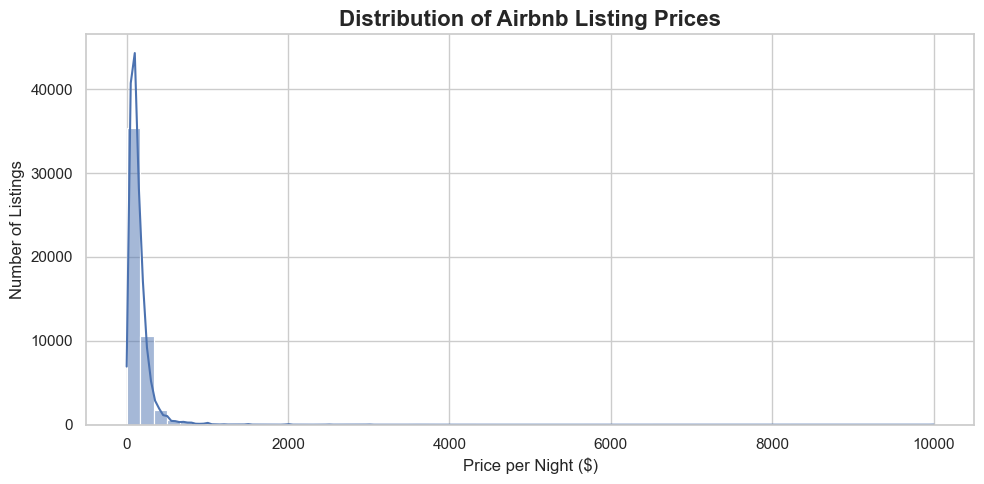

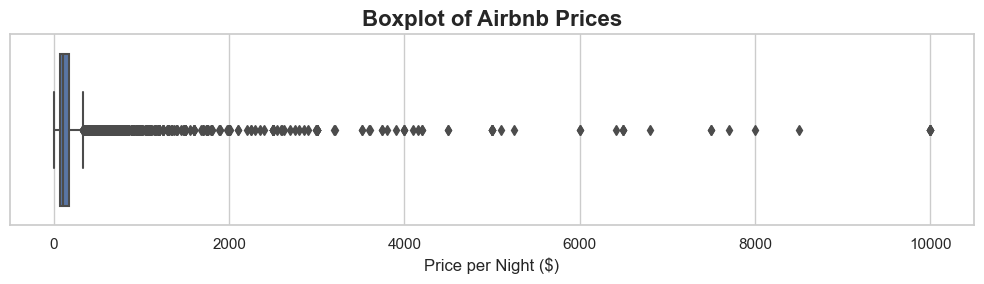

In [6]:
# Basic price statistics
print("Price Statistics")
print("-" * 30)
print(f"Mean Price   : ${df['price'].mean():.2f}")
print(f"Median Price : ${df['price'].median():.2f}")
print(f"Minimum Price: ${df['price'].min():.2f}")
print(f"Maximum Price: ${df['price'].max():.2f}")
print(f"95th Percentile: ${df['price'].quantile(0.95):.2f}")
print(f"99th Percentile: ${df['price'].quantile(0.99):.2f}")

# Set plotting style
sns.set_theme(style="whitegrid")

# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=60, kde=True)

plt.title("Distribution of Airbnb Listing Prices", fontsize=16, fontweight="bold")
plt.xlabel("Price per Night ($)", fontsize=12)
plt.ylabel("Number of Listings", fontsize=12)
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['price'])

plt.title("Boxplot of Airbnb Prices", fontsize=16, fontweight="bold")
plt.xlabel("Price per Night ($)", fontsize=12)
plt.tight_layout()
plt.show()

As we can see Price is highly right-skewed.

In [7]:
df[df['price'] == 0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,2019-06-15,4.28,6,176
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,2019-06-21,4.37,6,232
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,2019-06-23,4.35,6,222
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,NaN,NaN,1,0
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,2019-06-22,0.11,6,333


### PRICE OUTLIER ANALYSIS

In [8]:
# Price outlier investigation

price = df["price"]

print("PRICE OUTLIER ANALYSIS")
print("=" * 40)

# Zero-price listings
zero_price = (price == 0).sum()
print(f"Zero-price listings : {zero_price}")
print(f"Percentage of data  : {zero_price / len(df) * 100:.2f}%")

# High-price listings
for threshold in [500, 1000, 2000, 5000]:
    count = (price > threshold).sum()
    percentage = count / len(df) * 100
    print(f"Price > ${threshold:<4}      : {count:>5} ({percentage:.2f}%)")

# IQR calculation
Q1 = price.quantile(0.25)
Q3 = price.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nIQR ANALYSIS")
print("=" * 40)
print(f"Q1          : ${Q1:.2f}")
print(f"Q3          : ${Q3:.2f}")
print(f"IQR         : ${IQR:.2f}")
print(f"Lower bound : ${lower_bound:.2f}")
print(f"Upper bound : ${upper_bound:.2f}")

# Number of IQR outliers
iqr_outliers = ((price < lower_bound) | (price > upper_bound)).sum()

print(f"IQR outliers: {iqr_outliers}")
print(f"Percentage   : {iqr_outliers / len(df) * 100:.2f}%")

# Most expensive listings
print("\n10 MOST EXPENSIVE LISTINGS")
print("=" * 40)

display(
    df[["id", "name", "neighbourhood_group", "neighbourhood",
        "room_type", "price"]]
    .sort_values("price", ascending=False)
    .head(10)
)

PRICE OUTLIER ANALYSIS
Zero-price listings : 11
Percentage of data  : 0.02%
Price > $500       :  1044 (2.14%)
Price > $1000      :   239 (0.49%)
Price > $2000      :    86 (0.18%)
Price > $5000      :    20 (0.04%)

IQR ANALYSIS
Q1          : $69.00
Q3          : $175.00
IQR         : $106.00
Lower bound : $-90.00
Upper bound : $334.00
IQR outliers: 2972
Percentage   : 6.08%

10 MOST EXPENSIVE LISTINGS


,id,name,neighbourhood_group,neighbourhood,room_type,price
9151,7003697,Furnished room in Astoria apartment,Queens,Astoria,Private room,10000
17692,13894339,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Greenpoint,Entire home/apt,10000
29238,22436899,1-BR Lincoln Center,Manhattan,Upper West Side,Entire home/apt,10000
40433,31340283,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Lower East Side,Entire home/apt,9999
12342,9528920,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Lower East Side,Private room,9999
6530,4737930,Spanish Harlem Apt,Manhattan,East Harlem,Entire home/apt,9999
30268,23377410,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Tribeca,Entire home/apt,8500
4377,2953058,Film Location,Brooklyn,Clinton Hill,Entire home/apt,8000
29662,22779726,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Upper East Side,Entire home/apt,7703
42523,33007610,70' Luxury MotorYacht on the Hudson,Manhattan,Battery Park City,Entire home/apt,7500


In [9]:
# Investigate extreme high-price listings

price_99 = df["price"].quantile(0.99)

extreme_prices = df[df["price"] > price_99]

print(f"99th percentile price: ${price_99:.2f}")
print(f"Listings above 99th percentile: {len(extreme_prices)}")
print(f"Percentage of dataset: {len(extreme_prices) / len(df) * 100:.2f}%")

print("\nRoom Type Distribution:")
display(extreme_prices["room_type"].value_counts())

print("\nNeighbourhood Group Distribution:")
display(extreme_prices["neighbourhood_group"].value_counts())

print("\nExtreme Price Statistics:")
display(extreme_prices["price"].describe())

print("\nSample of Extreme-Price Listings:")
display(
    extreme_prices[
        ["id", "name", "neighbourhood_group",
         "neighbourhood", "room_type",
         "minimum_nights", "number_of_reviews", "price"]
    ]
    .sort_values("price", ascending=False)
    .head(20)
)

99th percentile price: $799.00
Listings above 99th percentile: 474
Percentage of dataset: 0.97%

Room Type Distribution:


Entire home/apt    385
Private room        82
Shared room          7
Name: room_type, dtype: int64


Neighbourhood Group Distribution:


Manhattan        348
Brooklyn         103
Queens            16
Staten Island      4
Bronx              3
Name: neighbourhood_group, dtype: int64


Extreme Price Statistics:


count      474.000000
mean      1703.088608
std       1557.799196
min        800.000000
25%        900.000000
50%       1033.000000
75%       1799.750000
max      10000.000000
Name: price, dtype: float64


Sample of Extreme-Price Listings:


,id,name,neighbourhood_group,neighbourhood,room_type,minimum_nights,number_of_reviews,price
9151,7003697,Furnished room in Astoria apartment,Queens,Astoria,Private room,100,2,10000
29238,22436899,1-BR Lincoln Center,Manhattan,Upper West Side,Entire home/apt,30,0,10000
17692,13894339,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Greenpoint,Entire home/apt,5,5,10000
6530,4737930,Spanish Harlem Apt,Manhattan,East Harlem,Entire home/apt,5,1,9999
12342,9528920,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Lower East Side,Private room,99,6,9999
40433,31340283,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Lower East Side,Entire home/apt,30,0,9999
30268,23377410,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Tribeca,Entire home/apt,30,2,8500
4377,2953058,Film Location,Brooklyn,Clinton Hill,Entire home/apt,1,1,8000
29662,22779726,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Upper East Side,Entire home/apt,1,0,7703
42523,33007610,70' Luxury MotorYacht on the Hudson,Manhattan,Battery Park City,Entire home/apt,1,0,7500


In [10]:
# Missing Value Analysis

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing["Missing Count"] > 0].sort_values(
    "Missing Count", ascending=False
)

print("Missing Values Summary")
print("=" * 40)

display(missing)

Missing Values Summary


,Missing Count,Missing Percentage
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03


In [11]:
# Investigate the relationship between missing reviews and review counts

missing_reviews = df[
    df["last_review"].isnull() &
    df["reviews_per_month"].isnull()
]

print("Rows missing both last_review and reviews_per_month:", len(missing_reviews))

print("\nNumber of reviews among these listings:")
display(missing_reviews["number_of_reviews"].value_counts().head(10))

print("\nSummary of number_of_reviews:")
display(missing_reviews["number_of_reviews"].describe())

Rows missing both last_review and reviews_per_month: 10052

Number of reviews among these listings:


0    10052
Name: number_of_reviews, dtype: int64


Summary of number_of_reviews:


count    10052.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: number_of_reviews, dtype: float64

In [12]:
# Check whether missing review information corresponds to zero reviews

zero_reviews = df["number_of_reviews"] == 0

print("Listings with zero reviews:", zero_reviews.sum())

print(
    "Listings with both missing review fields and zero reviews:",
    (df["last_review"].isnull() &
     df["reviews_per_month"].isnull() &
     zero_reviews).sum()
)

Listings with zero reviews: 10052
Listings with both missing review fields and zero reviews: 10052


In [13]:
# Check consistency of review-related missing values

zero_reviews = df["number_of_reviews"] == 0

print("Zero-review listings:", zero_reviews.sum())

print(
    "Zero-review listings with missing reviews_per_month:",
    (zero_reviews & df["reviews_per_month"].isnull()).sum()
)

print(
    "Zero-review listings with non-missing reviews_per_month:",
    (zero_reviews & df["reviews_per_month"].notnull()).sum()
)

print(
    "\nListings with reviews but missing reviews_per_month:",
    ((df["number_of_reviews"] > 0) &
     df["reviews_per_month"].isnull()).sum()
)

Zero-review listings: 10052
Zero-review listings with missing reviews_per_month: 10052
Zero-review listings with non-missing reviews_per_month: 0

Listings with reviews but missing reviews_per_month: 0


## Handling missing values

In [14]:
# Handle missing values

# Drop last_review because of high missingness
df = df.drop(columns=["last_review"])

# Missing reviews_per_month means the listing has no reviews
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# Fill missing text values
df["name"] = df["name"].fillna("Unknown")
df["host_name"] = df["host_name"].fillna("Unknown")

print("Missing values after treatment:")
display(df.isnull().sum())

Missing values after treatment:


id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

#### Handling Missing Values

- **`last_review` — Drop the column**
  - 20.56% of the values are missing.
  - It is a raw date field and provides limited direct value for the price model.
  - `number_of_reviews` and `reviews_per_month` provide more useful review-related information.

- **`reviews_per_month` — Replace missing values with `0`**
  - Missing values correspond to listings with no recorded reviews.
  - Therefore, `0` appropriately represents the underlying meaning.

- **`name` — Replace missing values with `"Unknown"`**
  - Only 16 values are missing.
  - The column will be retained for feature engineering, where features such as name length may be explored.

- **`host_name` — Replace missing values with `"Unknown"`**
  - Only 21 values are missing.
  - The column will be retained initially, with its usefulness evaluated during feature selection.

In [15]:
# Price outlier treatment

original_rows = len(df)

# Calculate the 99th percentile threshold
price_99 = df["price"].quantile(0.99)

# Remove invalid zero-price listings
df = df[df["price"] > 0].copy()

# Remove extreme high-price listings above the 99th percentile
df = df[df["price"] <= price_99].copy()

# Calculate number of removed rows
removed_rows = original_rows - len(df)

print("PRICE OUTLIER TREATMENT")
print("=" * 40)
print(f"Original rows : {original_rows}")
print(f"Final rows    : {len(df)}")
print(f"Rows removed  : {removed_rows}")
print(f"Data retained : {len(df) / original_rows * 100:.2f}%")

print("\nPrice Statistics After Treatment")
print("=" * 40)
print(f"Minimum price : ${df['price'].min():.2f}")
print(f"Maximum price : ${df['price'].max():.2f}")
print(f"Median price  : ${df['price'].median():.2f}")
print(f"Mean price    : ${df['price'].mean():.2f}")

PRICE OUTLIER TREATMENT
Original rows : 48895
Final rows    : 48410
Rows removed  : 485
Data retained : 99.01%

Price Statistics After Treatment
Minimum price : $10.00
Maximum price : $799.00
Median price  : $105.00
Mean price    : $137.58


#### Outlier Treatment

The `price` variable showed a strong right-skewed distribution with several extreme values. 
An IQR-based method identified 2,972 observations as potential outliers; however, using this 
criterion would remove over 6% of the dataset and could eliminate legitimate high-priced Airbnb listings.

Therefore, a conservative 99th-percentile approach was used. Listings with `price = 0` were 
treated as invalid target values and removed, while listings with prices above the 99th percentile 
($799) were excluded as extreme upper-tail observations.

This resulted in the removal of 485 observations, reducing the dataset from 48,895 to 48,410 
records while retaining 99.01% of the original data. After treatment, prices ranged from $10 to $799, 
with a median price of $105 and a mean price of $137.58.

## Feature Analysis

In [16]:
# Select numerical features
numerical_features = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "latitude",
    "longitude"
]

# Descriptive statistics
print("Descriptive Statistics of Numerical Features")
print("=" * 50)

display(df[numerical_features].describe().T)

Descriptive Statistics of Numerical Features


,count,mean,std,min,25%,50%,75%,max
price,48410.0,137.575170,103.780081,10.00000,69.00000,105.00000,175.000000,799.00000
minimum_nights,48410.0,6.979508,20.293249,1.00000,1.00000,3.00000,5.000000,1250.00000
number_of_reviews,48410.0,23.412663,44.700109,0.00000,1.00000,5.00000,24.000000,629.00000
reviews_per_month,48410.0,1.096716,1.601074,0.00000,0.04000,0.38000,1.600000,58.50000
calculated_host_listings_count,48410.0,7.179860,33.094503,1.00000,1.00000,1.00000,2.000000,327.00000
availability_365,48410.0,112.094195,131.258152,0.00000,0.00000,44.00000,224.000000,365.00000
latitude,48410.0,40.728910,0.054621,40.49979,40.68996,40.72290,40.763160,40.91306
longitude,48410.0,-73.951934,0.046166,-74.24442,-73.98285,-73.95549,-73.935972,-73.71299


In [17]:
# Correlation with price

price_correlation = (
    df[numerical_features]
    .corr()["price"]
    .sort_values(ascending=False)
)

print("Correlation of Numerical Features with Price")
print("=" * 50)

display(price_correlation)

Correlation of Numerical Features with Price


price                             1.000000
calculated_host_listings_count    0.151287
availability_365                  0.113333
latitude                          0.067099
minimum_nights                    0.024382
reviews_per_month                -0.053053
number_of_reviews                -0.055553
longitude                        -0.273628
Name: price, dtype: float64

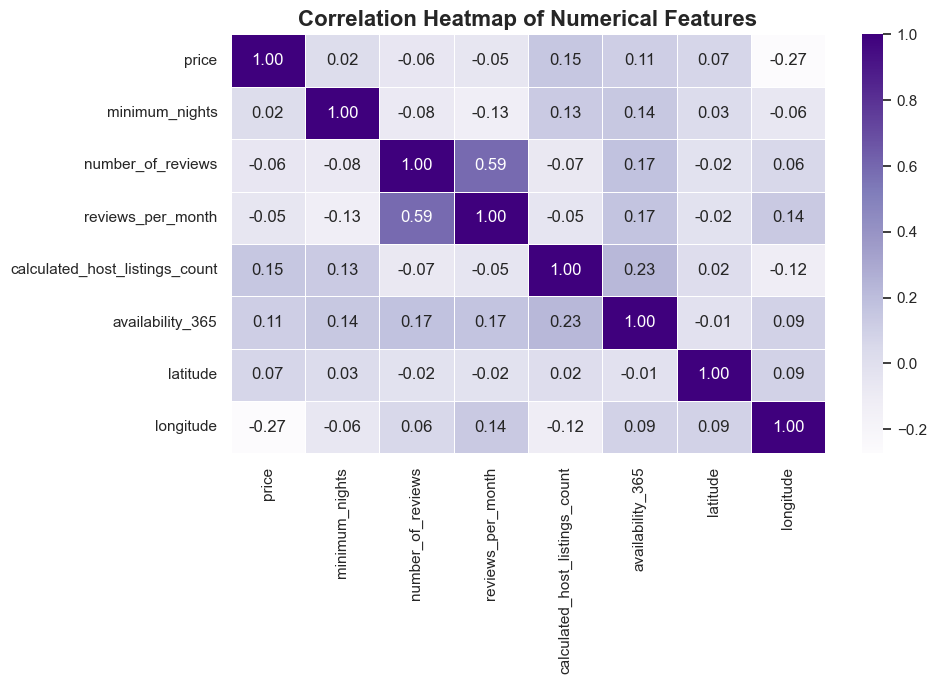

In [18]:
# Correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numerical_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="Purples",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### Categorical and Location Feature Analysis

Categorical and location-based variables were analysed to identify differences in Airbnb prices across 
room types and geographical areas. Average prices and listing counts were compared for each category 
to identify important pricing patterns.

In [19]:
# Room type analysis

room_type_analysis = (
    df.groupby("room_type")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

print("Price Analysis by Room Type")
print("=" * 45)

display(room_type_analysis)

Price Analysis by Room Type


,count,mean,median
room_type,,,
Entire home/apt,25022,189.100272,160.0
Private room,22237,83.394747,70.0
Shared room,1151,64.203301,45.0


In [20]:
# Neighbourhood group analysis

neighbourhood_analysis = (
    df.groupby("neighbourhood_group")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

print("Price Analysis by Neighbourhood Group")
print("=" * 50)

display(neighbourhood_analysis)

Price Analysis by Neighbourhood Group


,count,mean,median
neighbourhood_group,,,
Manhattan,21312,172.901886,149.0
Brooklyn,19992,115.921519,90.0
Staten Island,369,94.241192,75.0
Queens,5650,94.104779,75.0
Bronx,1087,83.862925,65.0


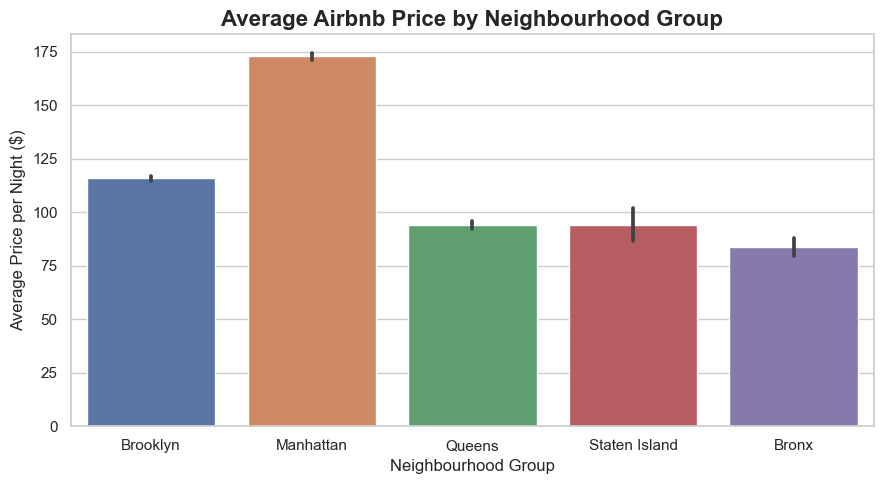

In [21]:
# Average price by neighbourhood group

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="neighbourhood_group",
    y="price",
    estimator="mean"
)

plt.title(
    "Average Airbnb Price by Neighbourhood Group",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price per Night ($)")
plt.tight_layout()
plt.show()


#### Feature Selection

Feature selection was performed by considering the data type, cardinality, 
predictive relevance, redundancy, and domain meaning of each variable. 
Identifier-like variables and features with limited predictive value were 
considered for removal, while location, room type, listing characteristics, 
and review-related variables were evaluated as potential predictors.

In [22]:
# Feature selection assessment

feature_assessment = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Unique Ratio (%)": (df.nunique() / len(df) * 100).round(2),
    "Missing Values": df.isnull().sum()
})

feature_assessment = feature_assessment.sort_values(
    "Unique Values", ascending=False
)

display(feature_assessment)

,Data Type,Unique Values,Unique Ratio (%),Missing Values
id,int64,48410,100.00,0
name,object,47428,97.97,0
host_id,int64,37109,76.66,0
latitude,float64,18989,39.23,0
longitude,float64,14685,30.33,0
host_name,object,11362,23.47,0
reviews_per_month,float64,938,1.94,0
price,int64,533,1.10,0
number_of_reviews,int64,394,0.81,0
availability_365,int64,366,0.76,0


In [23]:
# Identify potential identifier-like features

print("Potential identifier / high-cardinality features")
print("=" * 50)

for column in ["id", "host_id", "host_name", "name", "neighbourhood"]:
    print(
        f"{column:<25} "
        f"Unique: {df[column].nunique():>6} | "
        f"Unique Ratio: {df[column].nunique() / len(df) * 100:>6.2f}%"
    )

Potential identifier / high-cardinality features
id                        Unique:  48410 | Unique Ratio: 100.00%
host_id                   Unique:  37109 | Unique Ratio:  76.66%
host_name                 Unique:  11362 | Unique Ratio:  23.47%
name                      Unique:  47428 | Unique Ratio:  97.97%
neighbourhood             Unique:    220 | Unique Ratio:   0.45%


In [24]:
# Create a separate modeling dataset
model_df = df.copy()

# Remove features excluded during feature selection
model_df = model_df.drop(
    columns=["id", "host_id", "host_name", "name"]
)

The `id` and `host_id` columns were excluded because they are identifiers and 
their numeric values do not have meaningful predictive interpretations.

The `host_name` and raw `name` columns were also excluded because of their high 
cardinality, which would result in a large number of categorical levels.

The location-related features `neighbourhood_group`, `neighbourhood`, `latitude`, 
and `longitude` were retained because geographical information is relevant to 
Airbnb pricing. 

The `room_type` feature was also retained because substantial 
price differences were observed across room categories.

The remaining listing and review-related features were retained as potential 
predictors because their relationships with price may not be fully captured by 
simple correlation analysis.

### Feature Engineering

Feature engineering was performed to improve the representation of selected 
variables without introducing unnecessary or redundant features.

The `minimum_nights` variable showed a strong right-skewed distribution. 
Therefore, a logarithmic transformation using `log1p` was selected to reduce 
the effect of extreme values and provide a more suitable representation for 
modelling.

The transformation will be applied within the preprocessing pipeline so that 
the same operation is consistently applied to both training data and new 
observations.

No redundant derived features were retained. In particular, an availability 
ratio was not included because it is simply a rescaled version of 
`availability_365` and therefore does not provide additional information.

In [25]:

print("Modeling Dataset Shape:", model_df.shape)

print("\nRemaining Features:")
print(model_df.columns.tolist())

display(model_df.head())

Modeling Dataset Shape: (48410, 11)

Remaining Features:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


Other transformations, such as handling skewed numerical variables, will be 
performed later within the machine learning preprocessing pipeline to ensure that 
the same transformations are consistently applied to training data and new 
predictions.

-Numerical features=
latitude
longitude
minimum_nights
number_of_reviews
reviews_per_month
calculated_host_listings_count
availability_365


-Categorical features=
neighbourhood_group
neighbourhood
room_type

-Target=
price

### 2.7 Train-Test Split

The target variable `price` was separated from the predictor variables. The dataset 
was then divided into training and testing subsets using an 80:20 split.

The training set will be used to learn the preprocessing parameters and train the 
machine learning models, while the test set will be kept separate for final 
performance evaluation. This approach helps prevent data leakage and provides a 
more reliable estimate of model performance.

In [26]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = model_df.drop(columns=["price"])
y = model_df["price"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

print("\nTarget shapes:")
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Training set shape: (38728, 10)
Testing set shape : (9682, 10)

Target shapes:
y_train: (38728,)
y_test : (9682,)


In [27]:
print("Training target statistics:")
display(y_train.describe())

print("\nTesting target statistics:")
display(y_test.describe())

Training target statistics:


count    38728.000000
mean       137.313133
std        103.643888
min         10.000000
25%         69.000000
50%        105.000000
75%        175.000000
max        799.000000
Name: price, dtype: float64


Testing target statistics:


count    9682.000000
mean      138.623322
std       104.321867
min        10.000000
25%        69.000000
50%       105.000000
75%       175.000000
max       799.000000
Name: price, dtype: float64

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Categorical features
categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

# Numerical features excluding minimum_nights
numerical_features = [
    "latitude",
    "longitude",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

# Skewed numerical feature
log_features = ["minimum_nights"]

# Pipeline for minimum_nights
log_pipeline = Pipeline([
    ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

# Complete preprocessing transformer
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("log_num", log_pipeline, log_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

print("Preprocessing transformer created successfully.")

Preprocessing transformer created successfully.


#### *Interpratation*
Categorical features → One-Hot Encoding

(neighbourhood_group
neighbourhood
room_type
into numerical columns.)

Numerical features → Scaling


(latitude
longitude
minimum_nights
number_of_reviews
reviews_per_month
calculated_host_listings_count
availability_365
availability_ratio)

minimum_nights → Log transformation

Because:
median = 3
maximum = 1250

the distribution is strongly right-skewed.

We will use Column Transformer because we have different preprocessing requirements for different columns

Categorical ──→ OneHotEncoder
Numerical ────→ StandardScaler
Minimum nights → log1p → StandardScaler

ColumnTransformer lets us combine these cleanly into one preprocessing object.

In [29]:
# Fit preprocessing on training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Training data shape after preprocessing:", X_train_processed.shape)
print("Testing data shape after preprocessing:", X_test_processed.shape)

print("\nProcessed data type:", type(X_train_processed))

Training data shape after preprocessing: (38728, 233)
Testing data shape after preprocessing: (9682, 233)

Processed data type: <class 'scipy.sparse._csr.csr_matrix'>


In [40]:
from sklearn import set_config

# Display the pipeline as a visual diagram
set_config(display="diagram")

final_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['latitude', 'longitude',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'calculated_host_listings_count',
                                                   'availability_365']),
                                                 ('log_num',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['minimum_nights']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['neighbourhood_group',
                                                   'neighbourhood',
                                                   'room_type'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, max_features=0.5,
                                       min_samples_leaf=2, min_samples_split=10,
                                       n_estimators=150, n_jobs=-1,
                                       random_state=42))])

## Task 2

Comparison:

Linear Regression serves as your essential baseline, giving you a benchmark for minimum acceptable performance and highly interpretable coefficients.

Random Forest Regressor acts as a robust bagging model, which will easily capture non-linear relationships (like how price scales with room capacity) without overfitting.

Gradient Boosting Regressor acts as your high-performance boosting model, which focuses sequentially on correcting residual errors to push your prediction accuracy to its limit.

#### Linear regression model

Linear Regression was used as the baseline model for Airbnb price prediction.

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create and train Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

# Predictions
y_train_pred = linear_model.predict(X_train_processed)
y_test_pred = linear_model.predict(X_test_processed)

# Evaluation function
def evaluate_model(model_name, y_train, y_train_pred, y_test, y_test_pred):
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"{model_name}")
    print("-" * 40)
    print(f"Train MAE  : {train_mae:.2f}")
    print(f"Test MAE   : {test_mae:.2f}")
    print(f"Train RMSE : {train_rmse:.2f}")
    print(f"Test RMSE  : {test_rmse:.2f}")
    print(f"Train R²   : {train_r2:.4f}")
    print(f"Test R²    : {test_r2:.4f}")

evaluate_model(
    "Linear Regression",
    y_train, y_train_pred,
    y_test, y_test_pred
)

Linear Regression
----------------------------------------
Train MAE  : 49.51
Test MAE   : 49.94
Train RMSE : 79.42
Test RMSE  : 79.61
Train R²   : 0.4128
Test R²    : 0.4175


MAE ≈ $49.94: On average, the model's predicted price differs from the actual price by about $50.

RMSE ≈ $79.61: Larger prediction errors have a stronger effect, giving an error of about $80.

R² = 0.4175: The model explains about 41.75% of the variation in Airbnb prices.

The training and testing performance were very similar, suggesting that the model does not show significant overfitting. However, the moderate R² indicates that a linear model may not capture the nonlinear relationships between listing characteristics and price.


#### Random Forest Regressor

Random Forest Regressor was trained to capture nonlinear relationships between 
Airbnb listing characteristics and price.

In [31]:
from sklearn.ensemble import RandomForestRegressor

# Create and train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train_processed)
y_test_pred_rf = rf_model.predict(X_test_processed)

# Evaluation
evaluate_model(
    "Random Forest Regressor",
    y_train, y_train_pred_rf,
    y_test, y_test_pred_rf
)

Random Forest Regressor
----------------------------------------
Train MAE  : 16.76
Test MAE   : 44.95
Train RMSE : 27.84
Test RMSE  : 72.91
Train R²   : 0.9278
Test R²    : 0.5114


The model achieved a test MAE of $44.93, a test RMSE of $72.91, and a test R² of 
0.5115, outperforming the Linear Regression baseline.

However, the training R² of 0.9277 was substantially higher than the testing R² 
of 0.5115. 

The difference between training and testing performance indicates 
considerable overfitting.



#### Gradient Boosting

Gradient Boosting Regressor was trained to capture nonlinear relationships in 
the Airbnb pricing data.


In [32]:
from sklearn.ensemble import GradientBoostingRegressor

# Create and train Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_processed, y_train)

# Predictions
y_train_pred_gb = gb_model.predict(X_train_processed)
y_test_pred_gb = gb_model.predict(X_test_processed)

# Evaluation
evaluate_model(
    "Gradient Boosting Regressor",
    y_train, y_train_pred_gb,
    y_test, y_test_pred_gb
)


Gradient Boosting Regressor
----------------------------------------
Train MAE  : 46.01
Test MAE   : 46.39
Train RMSE : 74.98
Test RMSE  : 75.54
Train R²   : 0.4767
Test R²    : 0.4757



The model achieved a test MAE of $46.38, a test RMSE of $75.51, and a test R² 
of 0.4760. Its training and testing performance were very similar, indicating 
no significant evidence of overfitting.

However, Gradient Boosting performed slightly worse than the Random Forest 
model on the test set.

Therefore, Random Forest is currently the strongest 
candidate among the three initial models.

##### Comparison of all 3 models

In [33]:
# Model comparison results

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Test MAE": [
        mean_absolute_error(y_test, y_test_pred),
        mean_absolute_error(y_test, y_test_pred_rf),
        mean_absolute_error(y_test, y_test_pred_gb)
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_gb))
    ],
    "Test R²": [
        r2_score(y_test, y_test_pred),
        r2_score(y_test, y_test_pred_rf),
        r2_score(y_test, y_test_pred_gb)
    ]
})

display(model_comparison.round(4))

,Model,Test MAE,Test RMSE,Test R²
0,Linear Regression,49.9417,79.6134,0.4175
1,Random Forest,44.9484,72.9140,0.5114
2,Gradient Boosting,46.3852,75.5352,0.4757


Three regression models were evaluated using the same training and testing 
datasets: Linear Regression, Random Forest Regressor, and Gradient Boosting 
Regressor.

"Random Forest achieved the best initial test performance", with the lowest MAE ($44.93) and RMSE ($72.91), and the highest R² (0.5115). 

Gradient Boosting performed better than the Linear Regression baseline but did not outperform Random Forest.

Although Random Forest achieved the best predictive performance, the large  difference between its training and testing performance indicates overfitting. 

Therefore, Random Forest was selected as the primary candidate for hyperparameter tuning to improve its generalization to unseen data.

In short:

Linear Regression: weakest test performance, but stable. 

Gradient Boosting: improves over Linear Regression and has almost identical train/test performance. 

Random Forest: best test performance with MAE 44.9347, RMSE 72.9124, and R² 0.5115.Random Forest currently performs best on unseen data with the lowest MAE/RMSE and highest R², but its large train–test gap shows overfitting


#### Hyperparameter tuning

In [34]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# Random Forest model for faster hyperparameter tuning
rf_tuning_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Focused hyperparameter search space
param_distributions = {
    "n_estimators": [100, 150],
    "max_depth": [10, 15, 20],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt", 0.5]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning_model,
    param_distributions=param_distributions,
    n_iter=6,
    cv=2,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Run the search
rf_random_search.fit(X_train_processed, y_train)

print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-rf_random_search.best_score_)

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Best Parameters:
{'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15}

Best Cross-Validation RMSE:
74.16866147101926


Hyperparameters tuned:


- **`n_estimators`** — Controls the number of trees in the forest.
- **`max_depth`** — Controls how deep each tree can grow.
- **`min_samples_split`** — Prevents splitting nodes with very few observations.
- **`min_samples_leaf`** — Ensures each leaf contains a sufficient number of observations.
- **`max_features`** — Controls the number of features considered when splitting each tree.


The hyperparameter tuning was performed to improve model generalization.

A focused RandomizedSearchCV approach with 2-fold cross-validation was used to 
search different values of `n_estimators`, `max_depth`, `min_samples_split`, 
`min_samples_leaf`, and `max_features`.

The best parameter combination was:

- `n_estimators`: 150
- `max_depth`: 15
- `min_samples_split`: 10
- `min_samples_leaf`: 2
- `max_features`: 0.5

The best cross-validation RMSE was approximately 74.17. The selected hyperparameters will now be evaluated on the unseen test set to determine whether they improve generalization and reduce overfitting.

##### Evaluation

Original Random Forest vs Tuned Random Forest

In [35]:
# Get the best tuned Random Forest model
tuned_rf_model = rf_random_search.best_estimator_

# Predictions
y_train_pred_tuned = tuned_rf_model.predict(X_train_processed)
y_test_pred_tuned = tuned_rf_model.predict(X_test_processed)

# Evaluate tuned model
evaluate_model(
    "Tuned Random Forest Regressor",
    y_train, y_train_pred_tuned,
    y_test, y_test_pred_tuned
)

Tuned Random Forest Regressor
----------------------------------------
Train MAE  : 36.22
Test MAE   : 43.82
Train RMSE : 59.42
Test RMSE  : 71.81
Train R²   : 0.6713
Test R²    : 0.5261


The tuned Random Forest model was evaluated on both the training and unseen test 
datasets.

Test MAE decreased from $44.93 → $43.82

Test RMSE decreased from $72.91 → $71.81

Test R² increased from 0.5115 → 0.5261

Train R² dropped from 0.9277 → 0.6713, substantially reducing the overfitting.

Compared with the original Random Forest, the tuned model improved all three test metrics.The tuned Random Forest was therefore selected as the final model candidate.



In [36]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Create final Random Forest with the best parameters
final_rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

# Create final end-to-end pipeline
final_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", final_rf_model)
])

# Train the complete pipeline on raw training data
final_pipeline.fit(X_train, y_train)

print("Final pipeline trained successfully.")

Final pipeline trained successfully.


In [37]:
# Predictions using the complete final pipeline
y_train_pred_final = final_pipeline.predict(X_train)
y_test_pred_final = final_pipeline.predict(X_test)

# Evaluate final pipeline
evaluate_model(
    "Final Tuned Random Forest Pipeline",
    y_train, y_train_pred_final,
    y_test, y_test_pred_final
)

Final Tuned Random Forest Pipeline
----------------------------------------
Train MAE  : 36.22
Test MAE   : 43.82
Train RMSE : 59.42
Test RMSE  : 71.81
Train R²   : 0.6713
Test R²    : 0.5261


The train–test gap is much smaller than the original Random Forest, so tuning successfully reduced overfitting while also improving test performance.

In [38]:
final_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", final_rf_model)
])

The complete machine learning pipeline, consisting of the preprocessing workflow and tuned Random Forest Regressor, was evaluated on the unseen test dataset.

The final model achieved a test MAE of $43.82, a test RMSE of $71.81, and a test R² of 0.5261. The model explains approximately 52.61% of the variation in Airbnb prices.

The training R² was 0.6713 compared with a test R² of 0.5261. 

Although a difference remains, the gap is substantially smaller than that of the original Random Forest model, indicating that hyperparameter tuning reduced overfitting and improved generalization.

The tuned Random Forest pipeline was therefore selected as the final model.

##### Final Pipeline

In [41]:
import joblib

# Save the complete preprocessing + model pipeline
joblib.dump(final_pipeline, "airbnb_price_pipeline.pkl")

print("Final pipeline saved successfully.")

Final pipeline saved successfully.


In [42]:
import os

print(os.path.exists("airbnb_price_pipeline.pkl"))

True


In [43]:
# Load the saved pipeline
loaded_pipeline = joblib.load("airbnb_price_pipeline.pkl")

# Test prediction
sample_prediction = loaded_pipeline.predict(X_test.iloc[[0]])

print("Sample predicted price:", round(sample_prediction[0], 2))
print("Actual price:", y_test.iloc[0])

Sample predicted price: 124.24
Actual price: 179


The final preprocessing and tuned Random Forest model were saved together as `airbnb_price_pipeline.pkl` using `joblib`.

The saved pipeline was successfully loaded and tested on a sample from the test dataset.

It produced a predicted price of $124.24 compared with the actual price of $179.

This confirms that the complete preprocessing and prediction workflow has been successfully saved and can be reused for new Airbnb listing inputs.

### Application Testing

The Streamlit application was tested using three realistic Airbnb listing configurations from different neighbourhood groups and room types.

The Brooklyn private-room listing produced an estimated nightly price of $50.02, 
while the Manhattan entire-home/apt listing produced the highest estimated price of $222.22. 
The Queens private-room listing produced an estimated price of $83.40.

The results demonstrate that the application successfully accepts listing characteristics and generates price estimates using the saved machine learning pipeline.